# Axolver Experiment Reader

This notebook reads experiment logs from Axolver training runs and produces learning curves and result tables.

Set `dump_path` and `exp_names` below to point to your experiments.

In [1]:
import os
import ast
import pickle
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

# ── Configure your experiments here ──────────────────────────────────
dump_path = "/home/mahrud/polytopes/axolver/exp"  # path to the experiment root
exp_names = ["cy_facets_10M/cy_facets_10M"]  # list of exp_name directories
exp_names = ["cy_points_10M/cy_points_10M"]  # list of exp_name directories
exp_names = ["cy_points_10M/cy_points_10M-frozen-encoder"]  # list of exp_name directories
exp_names = ["cy_points_10M/cy_points_10M-changing-encoder"]  # list of exp_name directories
task_name = "CY_POLYTOPE"  # task name as it appears in log metrics

# ── Optional filters ─────────────────────────────────────────────────
xp_filter = {}  # e.g. {"outcome_distribution": ["uniform"]}
unwanted_args = ["dump_path", "command", "device", "global_rank", "is_master", "local_rank", "multi_gpu", "n_gpu_per_node", "world_size"]

## Reading Experiments

In [2]:
def find_experiments(dump_path, exp_names):
    """Find all experiment directories (dump_path/exp_name/exp_id)."""
    exps = []
    for name in exp_names:
        exp_dir = os.path.join(dump_path, name)
        if not os.path.isdir(exp_dir):
            print(f"Warning: {exp_dir} not found")
            continue
        for exp_id in sorted(os.listdir(exp_dir)):
            full = os.path.join(exp_dir, exp_id)
            if os.path.isdir(full) and os.path.exists(os.path.join(full, "train.log")):
                exps.append((name, exp_id, full))
    print(f"Found {len(exps)} experiment(s)")
    return exps


def read_params(exp_path):
    """Read params.pkl and return the parameter dict, or None."""
    pkl_path = os.path.join(exp_path, "params.pkl")
    if not os.path.exists(pkl_path):
        return None
    return pickle.load(open(pkl_path, "rb")).__dict__


def find_variable_args(all_params, unwanted_args):
    """Identify which args differ across experiments."""
    if not all_params:
        return set(), {}
    reference = all_params[0]
    all_keys = set()
    for p in all_params:
        all_keys.update(p.keys())
    variable = set()
    for key in all_keys:
        vals = [p.get(key) for p in all_params]
        if len(set(str(v) for v in vals)) > 1:
            variable.add(key)
    variable -= set(unwanted_args)
    common = {k: reference[k] for k in sorted(reference) if k not in variable and k not in unwanted_args}
    return variable, common


def read_experiment(exp_path):
    """Parse a train.log file and extract training loss, timing, and evaluation metrics."""
    result = {"path": exp_path, "train_loss": [], "epochs": [], "nans": False, "train_time": 0, "eval_time": 0}

    log_path = os.path.join(exp_path, "train.log")
    if not os.path.exists(log_path):
        return result

    epoch_start = None
    epoch_end = None
    curr_epoch = -1
    total_train = 0.0
    total_eval = 0.0

    def parse_timestamp(line):
        try:
            ts_str = line.split("INFO - ")[1].split(" - ")[0].strip()
            return datetime.strptime(ts_str, "%m/%d/%y %H:%M:%S")
        except (ValueError, IndexError):
            return None

    with open(log_path, "rt") as f:
        for line in f:
            # Training loss
            if "- LOSS:" in line:
                try:
                    for part in line.strip().split(" - "):
                        if part.strip().startswith("LOSS:"):
                            result["train_loss"].append(float(part.strip().split()[-1]))
                except (ValueError, IndexError):
                    pass

            if "Starting epoch" in line:
                ts = parse_timestamp(line)
                if ts and epoch_end and curr_epoch > 0:
                    total_eval += (ts - epoch_end).total_seconds()
                epoch_start = ts
                try:
                    curr_epoch = int(line.split("epoch")[1].split("...")[0].strip())
                except (ValueError, IndexError):
                    pass

            if "End of epoch" in line:
                ts = parse_timestamp(line)
                if ts and epoch_start:
                    total_train += (ts - epoch_start).total_seconds()
                epoch_end = ts

            # __log__ lines
            if "__log__:" in line:
                try:
                    json_str = line[line.index("__log__:") + 8 :].strip()
                    if ": NaN," in json_str:
                        result["nans"] = True
                        json_str = json_str.replace(": NaN,", ": -1.0,")
                    metrics = ast.literal_eval(json_str)
                    result["epochs"].append(metrics)
                except (ValueError, SyntaxError):
                    pass

    n = len(result["epochs"])
    if n > 0:
        result["train_time"] = round(total_train / n)
        result["eval_time"] = round(total_eval / n)
    return result


def extract_series(result, task_name, metric):
    """Extract a metric series from epoch data. metric is e.g. 'acc', 'xe_loss'."""
    key = f"valid_{task_name}_{metric}"
    return [ep[key] for ep in result["epochs"] if key in ep]


def extract_class_accuracies(result, task_name):
    """Extract per-class accuracy series from the last epoch."""
    if not result["epochs"]:
        return {}
    last = result["epochs"][-1]
    prefix = f"valid_{task_name}_acc_"
    return {k.replace(prefix, ""): v for k, v in sorted(last.items()) if k.startswith(prefix)}


def filter_experiment(params, filt):
    """Return True if experiment params match all filter criteria."""
    if not filt or not params:
        return True
    for key, allowed in filt.items():
        if key not in params or params[key] not in allowed:
            return False
    return True


def make_label(d):
    """Build the display label for an experiment."""
    return f"{d['name']}/{d['exp_id']}"


# ── Find and read all experiments ────────────────────────────────────
experiments = find_experiments(dump_path, exp_names)
data = []
all_params = []

for name, exp_id, path in experiments:
    params = read_params(path)
    if not filter_experiment(params, xp_filter):
        continue
    r = read_experiment(path)
    r["name"] = name
    r["exp_id"] = exp_id
    r["params"] = params or {}
    all_params.append(r["params"])
    data.append(r)
    n_epochs = len(r["epochs"])
    best_acc = max(extract_series(r, task_name, "acc"), default=0)
    print(f"  {name}/{exp_id}: {n_epochs} epochs, best acc = {best_acc:.2f}%")

# ── Identify common vs variable hyperparameters ─────────────────────
var_args, common_args = find_variable_args(all_params, unwanted_args)

# ── Compute shared label width for all tables ────────────────────────
label_w = max(len("Experiment"), max((len(make_label(d)) for d in data), default=0)) + 2

if common_args:
    print(f"\n── Common args ({len(common_args)}) ──")
    for k, v in sorted(common_args.items()):
        print(f"  {k} = {v}")

if var_args:
    print(f"\n── Variable args ({len(var_args)}) ──")
    print(" ", ", ".join(sorted(var_args)))

Found 1 experiment(s)
  cy_points_10M/cy_points_10M-changing-encoder/16715251: 366 epochs, best acc = 88.82%

── Common args (75) ──
  activation = gelu
  amp = True
  architecture = encoder_decoder
  attention_dropout = 0
  base = 1000
  batch_size = 32
  batch_size_eval = 128
  beam_eval = False
  beam_length_penalty = 1
  beam_size = 1
  clip_grad_norm = 5
  cpu = False
  dec_emb_dim = 256
  dec_gated = False
  dec_loop_idx = -1
  dec_loops = 1
  dec_pos_emb = abs_learned
  decoder_loss_weights = 
  decoder_tasks = 
  decouple_cpu_gpu = False
  dropout = 0
  enc_emb_dim = 256
  enc_gated = False
  enc_loop_idx = -1
  enc_loops = 1
  enc_pos_emb = abs_learned
  env_base_seed = -1
  epoch_size = 300000
  eval_data = ../data/axolver-points-10M/valid.data,../data/axolver-points-10M/test.data
  eval_data_aux = 
  eval_from_exp = 
  eval_only = False
  eval_size = 5000
  eval_verbose = 0
  exp_id = 16715251
  exp_name = cy_points_10M-changing-encoder
  export_data = False
  first_class_pr

## Training Loss Curve

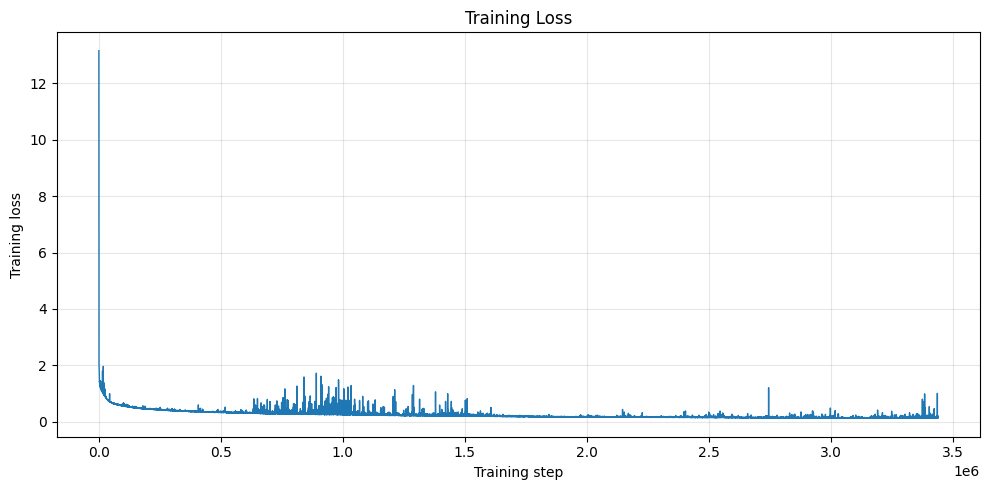

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
for d in data:
    if d["train_loss"]:
        report_every = d["params"]["report_loss_every"]
        steps = [report_every * (i + 1) for i in range(len(d["train_loss"]))]
        ax.plot(steps, d["train_loss"], linewidth=1, label=make_label(d))
ax.set_xlabel("Training step")
ax.set_ylabel("Training loss")
ax.set_title("Training Loss")
if len(data) > 1:
    ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Validation Accuracy Curve

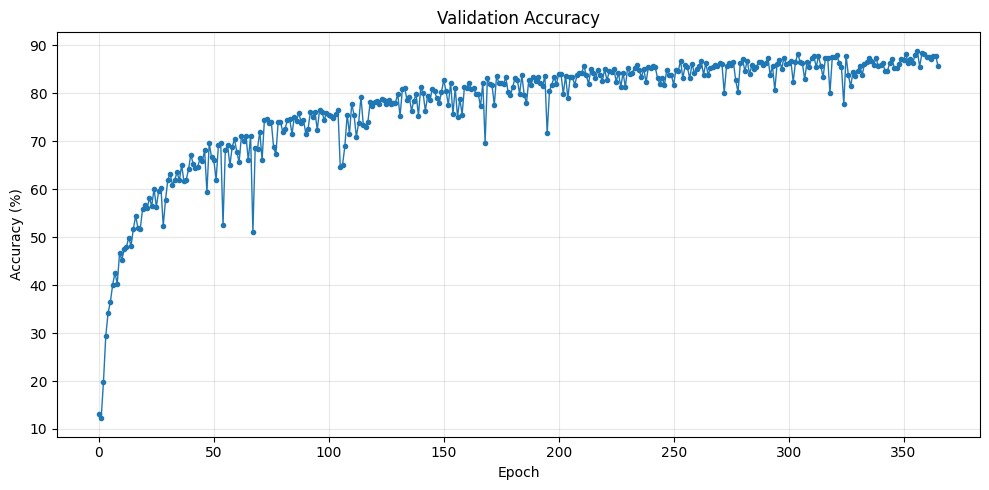

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
for d in data:
    acc = extract_series(d, task_name, "acc")
    if acc:
        ax.plot(acc, linewidth=1, marker="o", markersize=3, label=make_label(d))
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Validation Accuracy")
if len(data) > 1:
    ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Validation XE Loss Curve

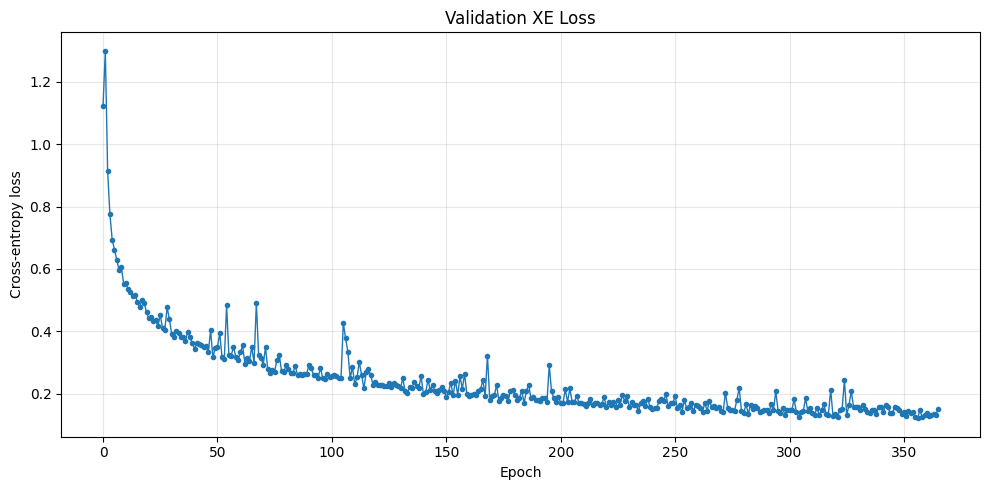

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
for d in data:
    xe = extract_series(d, task_name, "xe_loss")
    if xe:
        ax.plot(xe, linewidth=1, marker="o", markersize=3, label=make_label(d))
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss")
ax.set_title("Validation XE Loss")
if len(data) > 1:
    ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary Table

In [6]:
var_cols = sorted(var_args)
col_widths = {}
for v in var_cols:
    values = [str(d["params"].get(v, "")) for d in data]
    col_widths[v] = max(len(v), max((len(val) for val in values), default=0)) + 2

# ── Pre-compute all row data so we can measure column widths ─────────
rows = []
for d in data:
    acc = extract_series(d, task_name, "acc")
    xe = extract_series(d, task_name, "xe_loss")
    greedy = extract_series(d, task_name, "greedy_acc")
    wf = extract_series(d, task_name, "well_formed")
    if not acc:
        continue
    best_acc = max(acc)
    best_ep = acc.index(best_acc)
    last_acc = acc[-1]
    best_xe = min(xe) if xe else float("inf")
    last_greedy = greedy[-1] if greedy else 0
    last_wf = wf[-1] if wf else 0
    row = {
        "d": d,
        "n_epochs": len(acc),
        "best_acc": best_acc,
        "best_ep": best_ep,
        "last_acc": last_acc,
        "best_xe": best_xe,
        "last_greedy": last_greedy,
        "last_wf": last_wf,
    }
    # Pre-format each metric cell
    row["cells"] = {
        "Epochs": str(row["n_epochs"]),
        "Best Acc": f"{best_acc:.2f}%",
        "@Epoch": str(best_ep),
        "Last Acc": f"{last_acc:.2f}%",
        "XE Loss": f"{best_xe:.4f}",
        "Greedy": f"{last_greedy:.1f}%",
        "WellFrm": f"{last_wf:.1f}%",
        "NaN": "Y" if d["nans"] else "",
        "Train/ep": f"{d['train_time']}s",
        "Eval/ep": f"{d['eval_time']}s",
    }
    rows.append(row)

# ── Derive metric column widths from headers + actual data ───────────
metric_names = ["Epochs", "Best Acc", "@Epoch", "Last Acc", "XE Loss", "Greedy", "WellFrm", "NaN", "Train/ep", "Eval/ep"]
metric_w = {}
for m in metric_names:
    metric_w[m] = max(len(m), max((len(r["cells"][m]) for r in rows), default=0)) + 1

# ── Header ───────────────────────────────────────────────────────────
header = f"{'Experiment':<{label_w}}"
for v in var_cols:
    header += f" {v:>{col_widths[v]}}"
for m in metric_names:
    header += f" {m:>{metric_w[m]}}"

print(header)
print("-" * len(header))

for row in sorted(rows, key=lambda r: r["best_acc"], reverse=True):
    d = row["d"]
    line = f"{make_label(d):<{label_w}}"
    for v in var_cols:
        line += f" {str(d['params'].get(v, '')):>{col_widths[v]}}"
    for m in metric_names:
        line += f" {row['cells'][m]:>{metric_w[m]}}"
    print(line)

Experiment                                               Epochs  Best Acc  @Epoch  Last Acc  XE Loss  Greedy  WellFrm  NaN  Train/ep  Eval/ep
---------------------------------------------------------------------------------------------------------------------------------------------
cy_points_10M/cy_points_10M-changing-encoder/16715251       366    88.82%     356    85.54%   0.1205   80.5%   100.0%            70s       6s


## Per-Class Accuracy (last epoch)

Experiment                                                   13      15      16     17      18     19      20     21     22     23     24     25     26     27     28     29     30     31     32     33     34     35     36     37     38     39     40     41     42     43     44     45     46     47     48     49     50     51     52     53     54     55     56     57     58     59     60     61     62     63     64     65     66     67     68     69     70     71     72     73     74     75     76     77     78     79     80     81     82     83     84     85     86     87     88     89     90     91     92     93     94    95     96     97     98     99    100    101    102    103   104    105    106     107   108    109   110    111    112   113    114   115   116     118   119   120   121   122   123   124    125     126   127   128    129   130   131     132   133   135   136   137   139    140     141     143     148   150   152   153   154   159   161   164    167   169   173   17

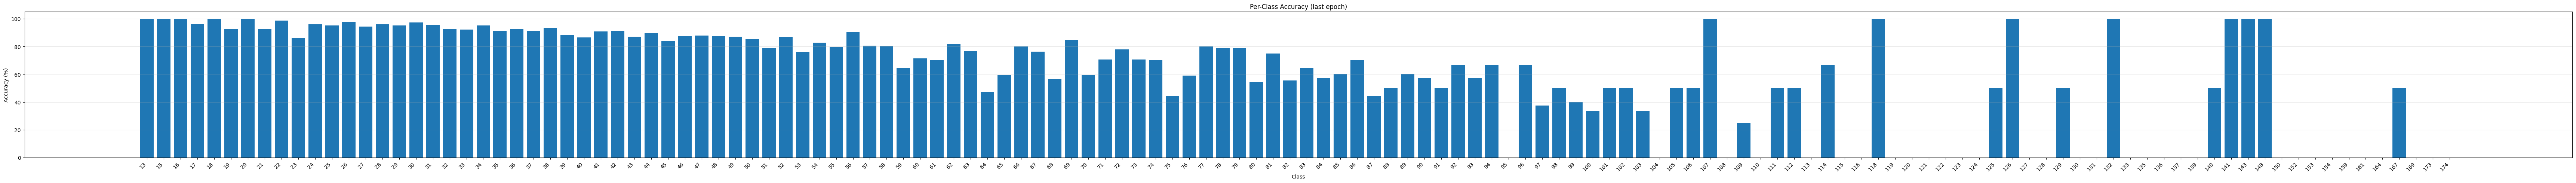

In [7]:
# Collect all class labels across experiments
all_classes = set()
for d in data:
    all_classes.update(extract_class_accuracies(d, task_name).keys())

if all_classes:
    try:
        sorted_classes = sorted(all_classes, key=int)
    except ValueError:
        sorted_classes = sorted(all_classes)

    # Pre-format all cells so we can measure widths
    class_cells = {}
    for d in data:
        ca = extract_class_accuracies(d, task_name)
        class_cells[make_label(d)] = {c: f"{ca[c]:.1f}%" if c in ca else "-" for c in sorted_classes}

    # Column width = max of header label and all formatted values
    cw = {}
    for c in sorted_classes:
        cw[c] = max(len(c), max(len(class_cells[make_label(d)][c]) for d in data)) + 1

    header = f"{'Experiment':<{label_w}}" + "".join(f" {c:>{cw[c]}}" for c in sorted_classes)
    print(header)
    print("-" * len(header))
    for d in data:
        line = f"{make_label(d):<{label_w}}"
        for c in sorted_classes:
            line += f" {class_cells[make_label(d)][c]:>{cw[c]}}"
        print(line)

    # Bar chart
    x = np.arange(len(sorted_classes))
    width = 0.8 / max(len(data), 1)
    fig, ax = plt.subplots(figsize=(max(10, len(sorted_classes) * 0.5), 5))
    for i, d in enumerate(data):
        ca = extract_class_accuracies(d, task_name)
        vals = [ca.get(c, 0) for c in sorted_classes]
        ax.bar(x + i * width, vals, width, label=make_label(d))
    ax.set_xlabel("Class")
    ax.set_ylabel("Accuracy (%)")
    ax.set_title("Per-Class Accuracy (last epoch)")
    ax.set_xticks(x + width * (len(data) - 1) / 2)
    ax.set_xticklabels(sorted_classes, rotation=45 if len(sorted_classes) > 15 else 0, ha="right")
    if len(data) > 1:
        ax.legend()
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()
else:
    print("No per-class accuracy data found.")

## Speed Table

First epoch where validation accuracy reaches the given threshold. Useful for comparing convergence speed across experiments.

In [8]:
def speed_table(data, task_name, thresholds=(50, 75, 90, 95, 99)):
    """Show the first epoch where accuracy reaches each threshold."""
    # Pre-format cells to measure widths
    thresh_headers = [f">={t}%" for t in thresholds]
    speed_cells = {}
    for d in data:
        acc = extract_series(d, task_name, "acc")
        cells = {}
        for i, t in enumerate(thresholds):
            first = next((j for j, v in enumerate(acc) if v >= t), None) if acc else None
            cells[thresh_headers[i]] = str(first) if first is not None else "—"
        speed_cells[make_label(d)] = cells

    # Column widths from headers + data
    tw = {}
    for h in thresh_headers:
        tw[h] = max(len(h), max((len(speed_cells[make_label(d)][h]) for d in data), default=0)) + 1

    header = f"{'Experiment':<{label_w}}" + "".join(f" {h:>{tw[h]}}" for h in thresh_headers)
    print(header)
    print("-" * len(header))
    for d in data:
        line = f"{make_label(d):<{label_w}}"
        for h in thresh_headers:
            line += f" {speed_cells[make_label(d)][h]:>{tw[h]}}"
        print(line)


speed_table(data, task_name)

Experiment                                               >=50%  >=75%  >=90%  >=95%  >=99%
------------------------------------------------------------------------------------------
cy_points_10M/cy_points_10M-changing-encoder/16715251       15     87      —      —      —
